# DX702 Coding Quiz 2

In [36]:
import pandas as pd
import numpy as np
import statsmodels.api as sm # For linear regression
import statsmodels.formula.api as smf
import scipy.stats as stats
import seaborn as sns

from sklearn.linear_model import LinearRegression
from scipy.stats import skew


Do a regression to estimate the fixed effect of each group. We assume that there is one single linear coefficient for all the data, plus the fixed effect of each group. Use the file homework_2.1.csv.  The variables G1, G2, and G3 are the outcomes and the time is the treatment.

### Question 1:  What's the coefficient (fixed effect) of group 1 ?  

In [23]:
# pd.set_option('display.max_rows', None)
# pd.set_option('display.max_columns', None)

df = pd.read_csv('homework_2.1.csv')
df.drop(columns=['Unnamed: 0'], inplace=True)
df


,time,G1,G2,G3
0,0,0.882026,1.441575,0.065409
1,1,0.210079,-0.163880,0.140310
2,2,0.509369,-0.115242,0.819830
3,3,1.150447,1.014698,0.607632
4,4,0.973779,-0.046562,0.610066
...,...,...,...,...
95,95,1.303287,1.364227,1.768446
96,96,0.965250,1.845895,1.258862
97,97,1.862935,1.881752,1.511477
98,98,1.043456,2.561618,1.030275


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   time    100 non-null    int64  
 1   G1      100 non-null    float64
 2   G2      100 non-null    float64
 3   G3      100 non-null    float64
dtypes: float64(3), int64(1)
memory usage: 3.3 KB


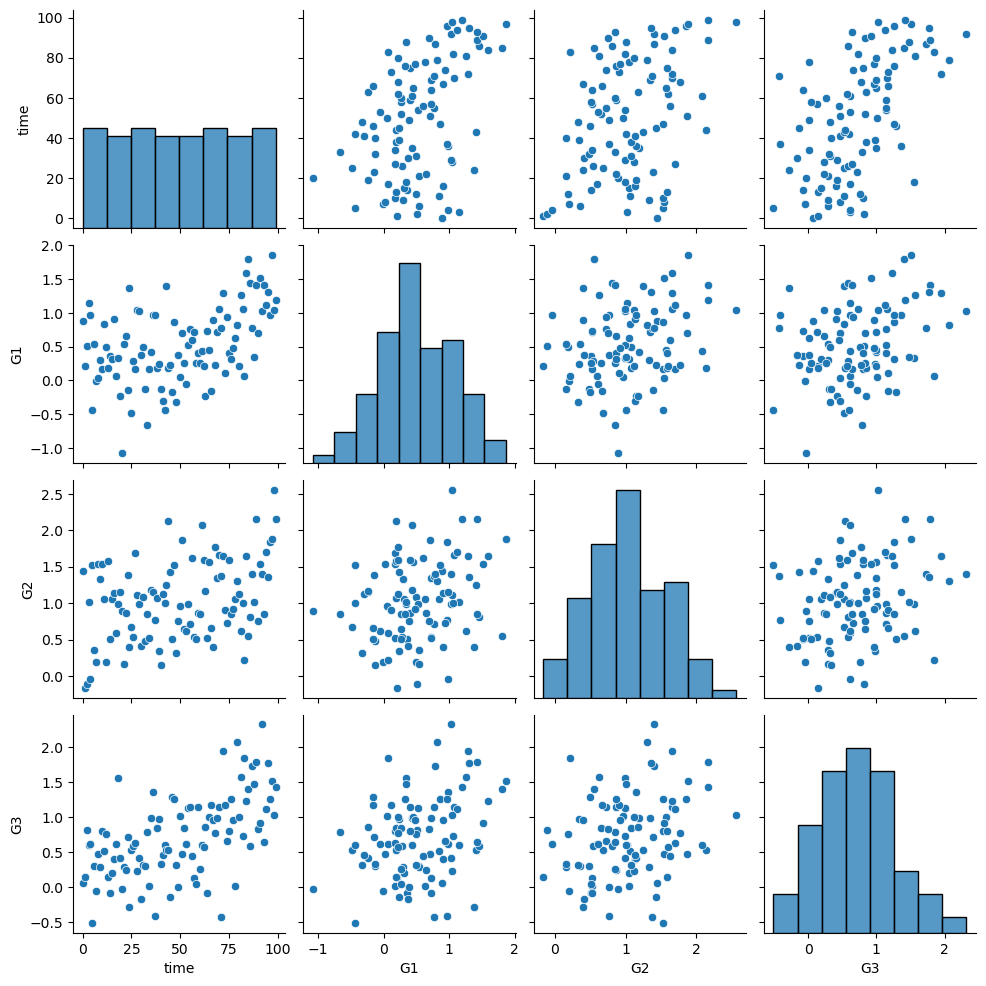

In [25]:
sns.pairplot(df)

In [26]:
# Melt df to long format, keeping 'time' as an identifier
# df_long = pd.melt(df, 
#                     id_vars     = ['time'], 
#                     # value_vars  = ['G1', 'G2', 'G3'], 
#                     value_vars  = ['G1'], 

#                     var_name    = 'group',
#                     value_name  ='outcome'
#                     )
# df_long

In [27]:
# Melt the dataframe from wide to long format for regression
df_melt = pd.melt(df, id_vars=['time'], value_vars=['G1', 'G2', 'G3'], var_name='group', value_name='value')

# Perform the regression using OLS with fixed effects for each group
model = smf.ols(formula='value ~ time + C(group)', data=df_melt)
results = model.fit()

# Print the regression summary
print(results.summary())

# Extract and print the coefficient for Group 1
fixed_effect_G1 = results.params['C(group)[T.G1]']
print(f"The fixed effect coefficient for Group 1 is: {fixed_effect_G1}")

                            OLS Regression Results                            
Dep. Variable:                  value   R-squared:                       0.311
Model:                            OLS   Adj. R-squared:                  0.304
Method:                 Least Squares   F-statistic:                     44.55
Date:                Mon, 29 Sep 2025   Prob (F-statistic):           8.72e-24
Time:                        21:28:10   Log-Likelihood:                -216.89
No. Observations:                 300   AIC:                             441.8
Df Residuals:                     296   BIC:                             456.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.0786      0.071      1.

KeyError: 'C(group)[T.G1]'

In [ ]:

# The model is `outcome ~ time + C(group)`.
# `C(group)` treats 'group' as a categorical variable, which will estimate the fixed effects for each group.

model   = smf.ols('outcome ~ time + C(group)', data = df_long)
results = model.fit()

print(results.summary().as_text())

                            OLS Regression Results                            
Dep. Variable:                outcome   R-squared:                       0.193
Model:                            OLS   Adj. R-squared:                  0.184
Method:                 Least Squares   F-statistic:                     23.40
Date:                Sun, 14 Sep 2025   Prob (F-statistic):           4.90e-06
Time:                        10:58:14   Log-Likelihood:                -72.993
No. Observations:                 100   AIC:                             150.0
Df Residuals:                      98   BIC:                             155.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.1042      0.101      1.035      0.3

In [ ]:
# coefficient of G1
intercept = results.params['Intercept']

print(f"Coefficient of G1: {intercept:.4f}")

Coefficient of G1: 0.1042


In [ ]:
options = ['A', 'B', 'C', 'D']
choices = [0.01023, 0.00850, 0.00485, 0.1823]
coeff_dist = abs(intercept - choices)
print(f'coeff_dist: {coeff_dist}')


answer_dict = dict(zip(options, choices))

coeff_dist: [0.09400572 0.09573572 0.09938572 0.07806428]


### Question 2: What's the common linear coefficient for all the groups ? 
Equivalently, what's the effect of `time` ?

In [ ]:
# Melt df to long format, keeping 'time' as an identifier
df_long_2 = pd.melt(df, 
                    id_vars     = ['time'], 
                    value_vars  = ['G1', 'G2', 'G3'], 
                    # value_vars  = ['G1'], 

                    var_name    = 'group',
                    value_name  ='outcome'
                    )
df_long_2

,time,group,outcome
0,0,G1,0.882026
1,1,G1,0.210079
2,2,G1,0.509369
3,3,G1,1.150447
4,4,G1,0.973779
...,...,...,...
295,95,G3,1.768446
296,96,G3,1.258862
297,97,G3,1.511477
298,98,G3,1.030275


In [ ]:
# The model is `outcome ~ time + C(group)`.
# `C(group)` treats 'group' as a categorical variable, which will estimate the fixed effects for each group.

model_2   = smf.ols('outcome ~ time + C(group)', data = df_long_2)
results_2 = model_2.fit()

print(results_2.summary().as_text())

                            OLS Regression Results                            
Dep. Variable:                outcome   R-squared:                       0.311
Model:                            OLS   Adj. R-squared:                  0.304
Method:                 Least Squares   F-statistic:                     44.55
Date:                Sun, 14 Sep 2025   Prob (F-statistic):           8.72e-24
Time:                        10:58:14   Log-Likelihood:                -216.89
No. Observations:                 300   AIC:                             441.8
Df Residuals:                     296   BIC:                             456.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.0786      0.071      1.

In [ ]:
common_linear_coeff = results_2.params['time']
print(f"Common linear coefficient: {common_linear_coeff:.4f}")

Common linear coefficient: 0.0090


-------------------------------------------
### For questions 3-5:

Given a data set, create a bootstrap simulation to try different possibilities. 
Use the file homework_2.2.csv 

In [28]:
path            = 'homework_2.2.csv'
n_samples       = 100000  # Number of bootstrap samples
random_state    = 42    # For reproducibility

In [29]:

data = pd.read_csv(path)
data.drop(columns=['Unnamed: 0'], inplace=True)  # Drop index column if it exists
# data

In [30]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       10000 non-null  int64  
 1   Y       10000 non-null  float64
 2   Z       10000 non-null  float64
dtypes: float64(2), int64(1)
memory usage: 234.5 KB


### Question 3: Mean Effect (Simple Subtraction) 
If we were to measure the effect of the treatment simply by subtracting the outcomes of the treated vs. untreated population, which of these is closest to the *mean effect*? (This is not the recommended way of measuring the mean effect when there are confounders!) 

In [31]:
treated_outcome     = data[data['X'] == 1]['Y'].mean()
untreated_outcome   = data[data['X'] == 0]['Y'].mean()

# Mean effect (non-recommended) 
mean_effect = treated_outcome - untreated_outcome
print(f"Mean effect (as simple difference of outcomes): {mean_effect:.4f}")

Mean effect (as simple difference of outcomes): 2.9207


### Question 4 : Variance of the Effect (Bootstrap, Simple Subtraction) 
If we were to use bootstrap sampling to measure the variance of that effect, again finding the effect using the non-recommended approach, which of these is closest to that variance?

In [32]:
n_samples = 10000
bootstrap_effects   = []

for _ in range(n_samples):
    bootstrap_sample = data.sample(n = len(data), replace = True)
    #calculate the effect for the bootstrap sample
    sample_treated_outcome      = bootstrap_sample[bootstrap_sample['X'] == 1]['Y'].mean()
    sample_untreated_outcome    = bootstrap_sample[bootstrap_sample['X'] == 0]['Y'].mean()
    effect                      = sample_treated_outcome - sample_untreated_outcome
    bootstrap_effects.append(effect)


variance_effect = np.var(bootstrap_effects)
print(f"Variance of effect (bootstrap, mean effect as simple difference of outcomes): {variance_effect:.4f}")



Variance of effect (bootstrap, mean effect as simple difference of outcomes): 0.0322


### Question 5: Skewness of the Effect (Linear Regression, Bootstrap) 
if we ran a linear regression (with intercept) to measure the effect, which of these is closest to the skewness of the effect measured? (Look up skewness online. You can use scipy.stats.skew to compute the skewness of a list of numbers.) 

In [38]:

# Prepare arrays to store bootstrap estimates
effects = []

# Perform bootstrap sampling and linear regression
for _ in range(n_samples):
    sample      = data.sample(n=len(data), replace=True)
    X_sample    = sample[['X']]
    Z_sample    = sample['Z']
    model       = LinearRegression()
    model.fit(X_sample, Z_sample)
    effects.append(model.coef_[0])

# Compute skewness of the effect estimates
effect_skewness = skew(effects)

print(f"Skewness of the estimated effect from bootstrap simulation: {effect_skewness}")


Skewness of the estimated effect from bootstrap simulation: 0.00028081550685760343


In [ ]:
def calculate_effect_regression(df):
    # Perform linear regression Y ~ X (intercept is included by default in smf.ols)
    model   = smf.ols('Y ~ X', data = df)
    results = model.fit()
    return results.params['X']

bootstrap_effects_regression = []

for _ in range(n_samples):
    bootstrap_sample    = data.sample(n = len(data), replace = True)
    effect              = calculate_effect_regression(bootstrap_sample)
    bootstrap_effects_regression.append(effect)

skewness_effect_regression = stats.skew(bootstrap_effects_regression)
print(f"Skewness of the effect (linear regression w/ bootstrap): {skewness_effect_regression:.4f}")

Skewness of the effect (linear regression w/ bootstrap): 0.0286
